In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

# So charts render inline in the notebook
%matplotlib inline

sns.set_style("whitegrid")

PROCESSED_DIR = Path("../data/processed")  # notebook lives in notebooks/, so go up one level
RAW_DIR = Path("../data/raw")
REPORTS_DIR = Path("../reports/charts")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)  # folder to save exported PNGs for the final report

In [2]:
nav_history = pd.read_csv(PROCESSED_DIR / "02_nav_history_clean.csv", parse_dates=['date'])
fund_master = pd.read_csv(PROCESSED_DIR / "01_fund_master_clean.csv")
aum_by_fund_house = pd.read_csv(PROCESSED_DIR / "03_aum_by_fund_house_clean.csv", parse_dates=['date'])
sip_inflows = pd.read_csv(PROCESSED_DIR / "04_monthly_sip_inflows_clean.csv")
category_inflows = pd.read_csv(PROCESSED_DIR / "05_category_inflows_clean.csv")
folio_count = pd.read_csv(PROCESSED_DIR / "06_industry_folio_count_clean.csv")
transactions = pd.read_csv(PROCESSED_DIR / "08_investor_transactions_clean.csv", parse_dates=['transaction_date'])
portfolio_holdings = pd.read_csv(PROCESSED_DIR / "09_portfolio_holdings_clean.csv")

print("All datasets loaded.")
print(f"nav_history: {nav_history.shape}")
print(f"fund_master: {fund_master.shape}")
print(f"aum_by_fund_house: {aum_by_fund_house.shape}")
print(f"sip_inflows: {sip_inflows.shape}")
print(f"category_inflows: {category_inflows.shape}")
print(f"folio_count: {folio_count.shape}")
print(f"transactions: {transactions.shape}")
print(f"portfolio_holdings: {portfolio_holdings.shape}")

All datasets loaded.
nav_history: (46000, 4)
fund_master: (40, 15)
aum_by_fund_house: (90, 5)
sip_inflows: (48, 6)
category_inflows: (144, 3)
folio_count: (21, 6)
transactions: (32778, 13)
portfolio_holdings: (322, 8)


In [3]:
nav_with_names = nav_history.merge(
    fund_master[['amfi_code', 'scheme_name', 'category']],
    on='amfi_code',
    how='left'
)

print(nav_with_names.shape)
nav_with_names.head()

(46000, 6)


,amfi_code,date,nav,daily_return_pct,scheme_name,category
0,100016,2022-01-03,520.4608,NaN,HDFC Top 100 Fund - Regular Plan - Growth,Equity
1,100016,2022-01-04,515.0971,-1.030568,HDFC Top 100 Fund - Regular Plan - Growth,Equity
2,100016,2022-01-05,521.7239,1.286515,HDFC Top 100 Fund - Regular Plan - Growth,Equity
3,100016,2022-01-06,515.7880,-1.137747,HDFC Top 100 Fund - Regular Plan - Growth,Equity
4,100016,2022-01-07,515.1639,-0.120999,HDFC Top 100 Fund - Regular Plan - Growth,Equity


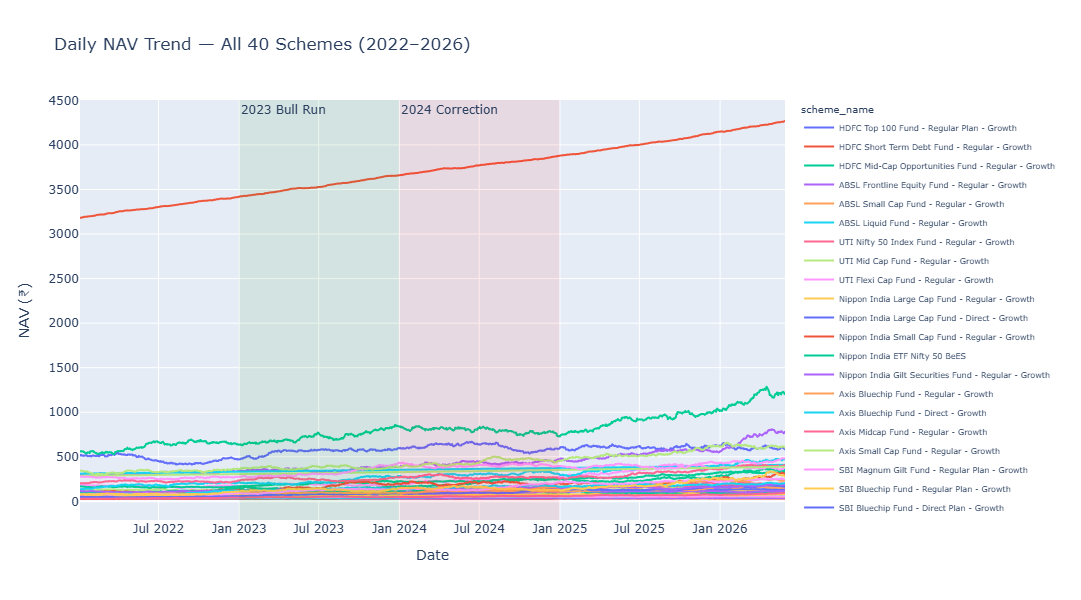

In [4]:
fig = px.line(
    nav_with_names,
    x='date',
    y='nav',
    color='scheme_name',
    title='Daily NAV Trend — All 40 Schemes (2022–2026)',
    labels={'nav': 'NAV (₹)', 'date': 'Date'},
)

# Highlight the 2023 bull run and 2024 correction as shaded background regions
fig.add_vrect(
    x0="2023-01-01", x1="2023-12-31",
    fillcolor="green", opacity=0.08, line_width=0,
    annotation_text="2023 Bull Run", annotation_position="top left"
)
fig.add_vrect(
    x0="2024-01-01", x1="2024-12-31",
    fillcolor="red", opacity=0.08, line_width=0,
    annotation_text="2024 Correction", annotation_position="top left"
)

fig.update_layout(height=600, legend=dict(font=dict(size=8)))
fig.show()

# Export as PNG for the final report
fig.write_image(str(REPORTS_DIR / "01_nav_trend_all_schemes.png"), width=1400, height=700)

In [5]:
print(sorted(aum_by_fund_house['date'].unique()))

[Timestamp('2022-03-31 00:00:00'), Timestamp('2022-09-30 00:00:00'), Timestamp('2023-03-31 00:00:00'), Timestamp('2023-09-30 00:00:00'), Timestamp('2024-03-31 00:00:00'), Timestamp('2024-09-30 00:00:00'), Timestamp('2024-12-31 00:00:00'), Timestamp('2025-03-31 00:00:00'), Timestamp('2025-12-31 00:00:00')]


In [6]:
aum_by_fund_house['year'] = aum_by_fund_house['date'].dt.year

# For each (fund_house, year), take the row with the LATEST date in that year
# This gives us the most recent available AUM snapshot per year, per fund house.
latest_idx = aum_by_fund_house.groupby(['fund_house', 'year'])['date'].idxmax()
aum_yearly = aum_by_fund_house.loc[latest_idx].copy()

# Show exactly which date was used as the "year-end proxy" for each year - transparency check
print(aum_yearly[['year', 'date']].drop_duplicates().sort_values('year'))

    year       date
15  2022 2022-09-30
35  2023 2023-09-30
65  2024 2024-12-31
85  2025 2025-12-31


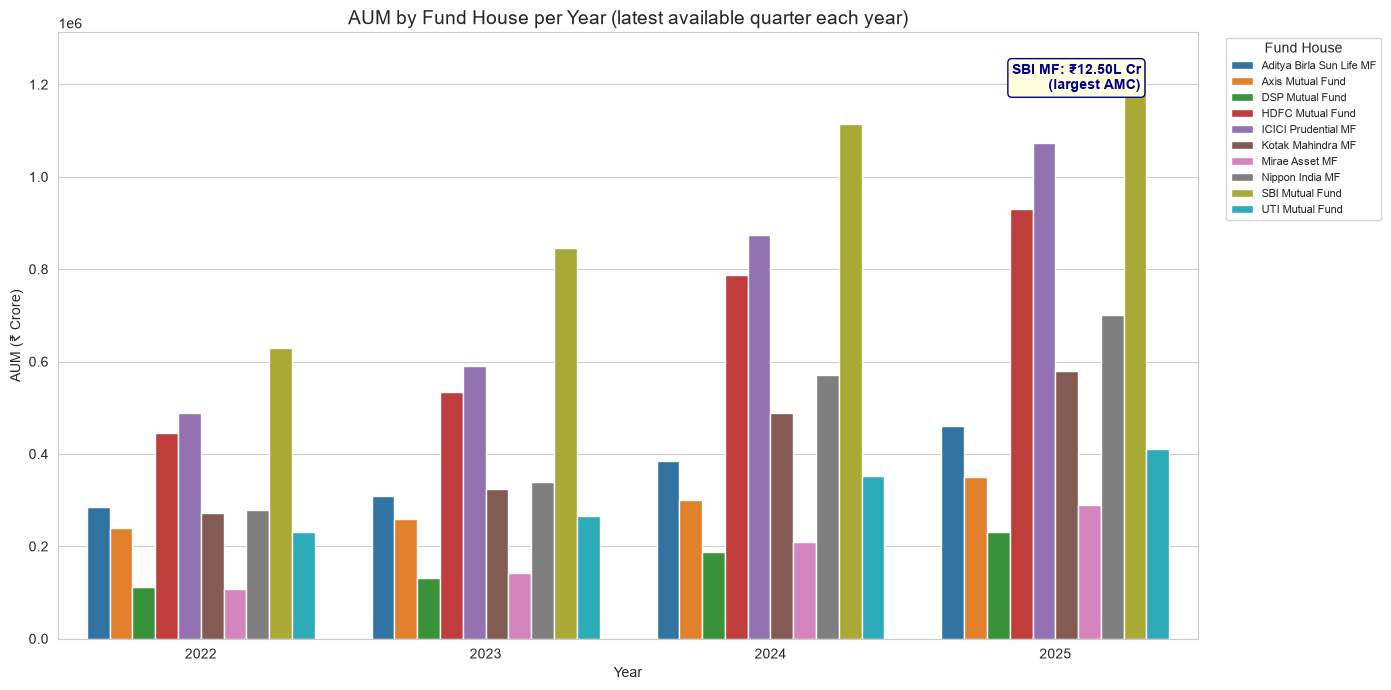

In [7]:
plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=aum_yearly,
    x='year',
    y='aum_crore',
    hue='fund_house',
)

plt.title("AUM by Fund House per Year (latest available quarter each year)", fontsize=14)
plt.ylabel("AUM (₹ Crore)")
plt.xlabel("Year")
plt.legend(title='Fund House', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

# Highlight SBI's bar in each year group with an annotation, since it's the dominant fund house
sbi_data = aum_yearly[aum_yearly['fund_house'] == 'SBI Mutual Fund']
for _, row in sbi_data.iterrows():
    pass  # we'll annotate the max year below instead, to avoid clutter

# Annotate the most recent year's SBI value specifically (matches the doc's "Rs.12.5L Cr" reference point)
latest_year = sbi_data['year'].max()
sbi_latest_value = sbi_data.loc[sbi_data['year'] == latest_year, 'aum_crore'].values[0]
plt.annotate(
    f"SBI MF: ₹{sbi_latest_value/100000:.2f}L Cr\n(largest AMC)",
    xy=(0.95, 0.95), xycoords='axes fraction',
    fontsize=10, fontweight='bold', color='darkblue',
    ha='right', va='top',
    bbox=dict(boxstyle="round", fc="lightyellow", ec="darkblue")
)

plt.tight_layout()
plt.savefig(REPORTS_DIR / "02_aum_by_fund_house_yearly.png", dpi=150, bbox_inches='tight')
plt.show()

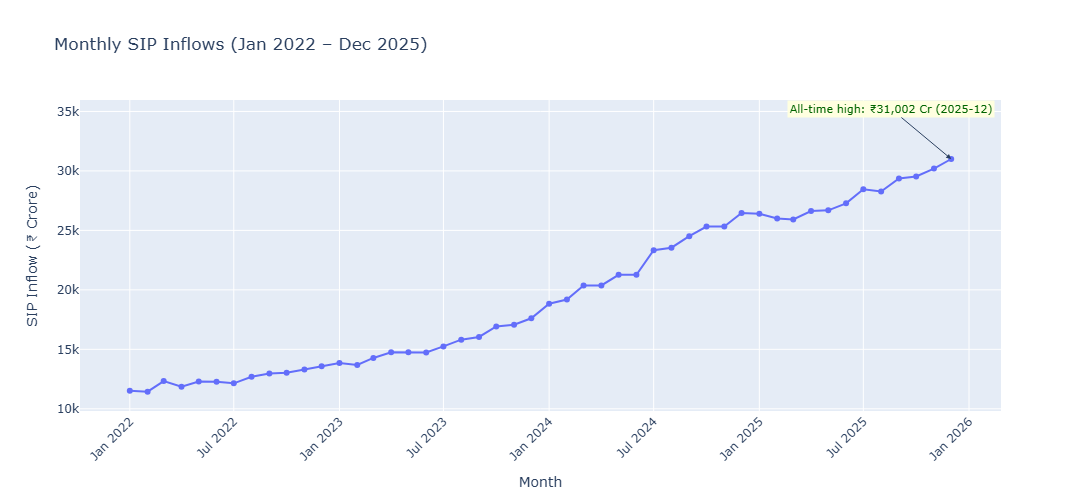

In [8]:
fig = px.line(
    sip_inflows,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflows (Jan 2022 – Dec 2025)',
    labels={'sip_inflow_crore': 'SIP Inflow (₹ Crore)', 'month': 'Month'},
    markers=True
)

# Annotate the all-time-high Dec 2025 milestone
peak_row = sip_inflows.loc[sip_inflows['sip_inflow_crore'].idxmax()]
fig.add_annotation(
    x=peak_row['month'], y=peak_row['sip_inflow_crore'],
    text=f"All-time high: ₹{peak_row['sip_inflow_crore']:,.0f} Cr ({peak_row['month']})",
    showarrow=True, arrowhead=2, ax=-60, ay=-50,
    font=dict(color="darkgreen", size=11),
    bgcolor="lightyellow"
)

fig.update_layout(height=500, xaxis_tickangle=-45)
fig.show()
fig.write_image(str(REPORTS_DIR / "03_sip_inflow_trend.png"), width=1200, height=600)

In [9]:
print(category_inflows.columns.tolist())
print(category_inflows.head())

['month', 'category', 'net_inflow_crore']
     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0


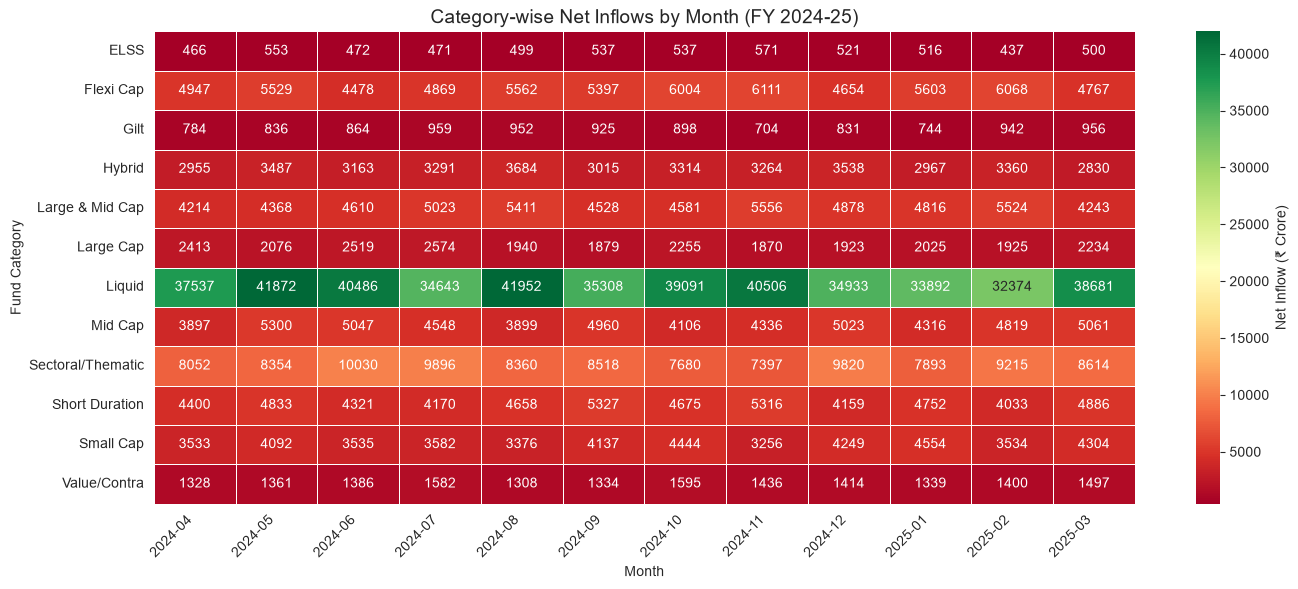

In [10]:
# Pivot: rows = category, columns = month, values = net_inflow_crore
heatmap_data = category_inflows.pivot(index='category', columns='month', values='net_inflow_crore')

plt.figure(figsize=(14, 6))
sns.heatmap(
    heatmap_data,
    cmap='RdYlGn',       # red = low/negative inflow, green = high inflow
    annot=True, fmt='.0f',
    linewidths=0.5,
    cbar_kws={'label': 'Net Inflow (₹ Crore)'}
)
plt.title("Category-wise Net Inflows by Month (FY 2024-25)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Fund Category")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(REPORTS_DIR / "04_category_inflow_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

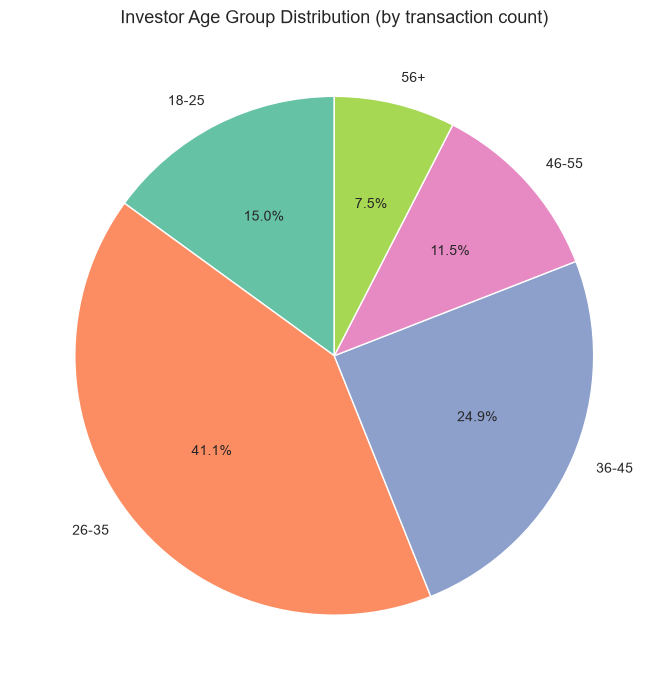

In [11]:
age_counts = transactions['age_group'].value_counts().sort_index()

plt.figure(figsize=(7, 7))
plt.pie(
    age_counts.values,
    labels=age_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set2')
)
plt.title("Investor Age Group Distribution (by transaction count)", fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "05a_age_distribution_pie.png", dpi=150, bbox_inches='tight')
plt.show()

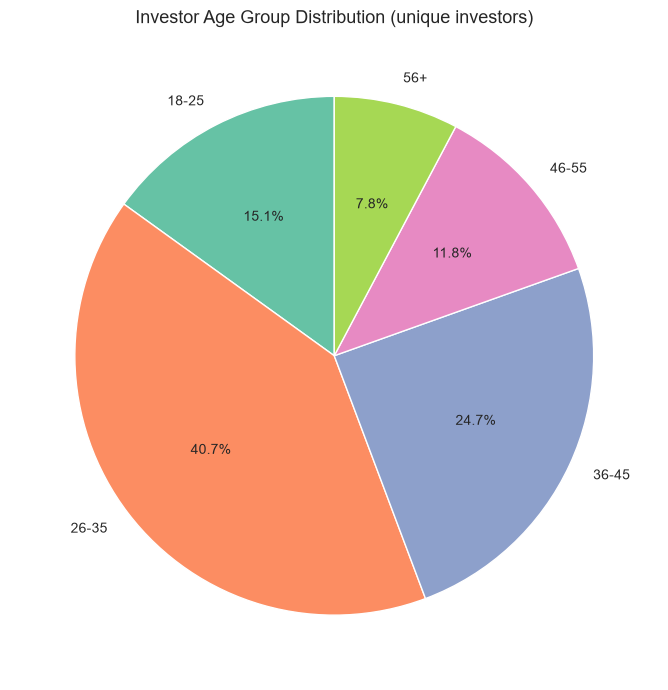

In [12]:
investor_age = transactions.drop_duplicates(subset='investor_id')['age_group'].value_counts().sort_index()

plt.figure(figsize=(7, 7))
plt.pie(
    investor_age.values,
    labels=investor_age.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set2')
)
plt.title("Investor Age Group Distribution (unique investors)", fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "05b_age_distribution_unique_investors.png", dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Sanity check: does any investor_id show more than one age_group value across their transactions?
inconsistent = transactions.groupby('investor_id')['age_group'].nunique()
print("Investors with inconsistent age_group across transactions:", (inconsistent > 1).sum())

Investors with inconsistent age_group across transactions: 0


C:\Users\Saumy\AppData\Local\Temp\ipykernel_25500\885075878.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


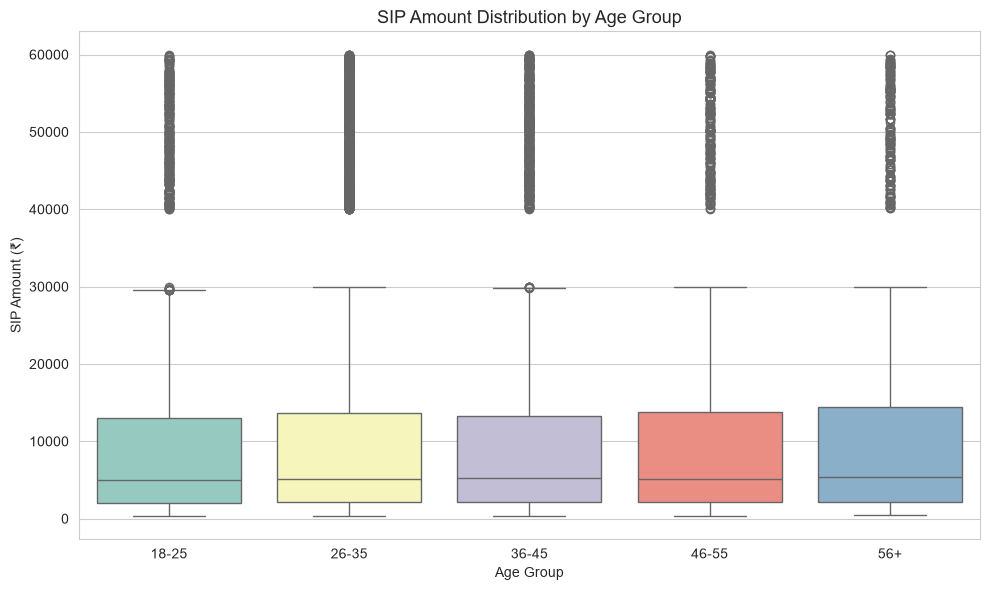

In [14]:
sip_only = transactions[transactions['transaction_type'] == 'SIP']

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=sip_only,
    x='age_group',
    y='amount_inr',
    order=sorted(sip_only['age_group'].unique()),
    palette='Set3'
)
plt.title("SIP Amount Distribution by Age Group", fontsize=13)
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "05c_sip_amount_by_age_boxplot.png", dpi=150, bbox_inches='tight')
plt.show()

gender
Male      3337
Female    1663
Name: count, dtype: int64
gender
Male      66.7
Female    33.3
Name: count, dtype: float64


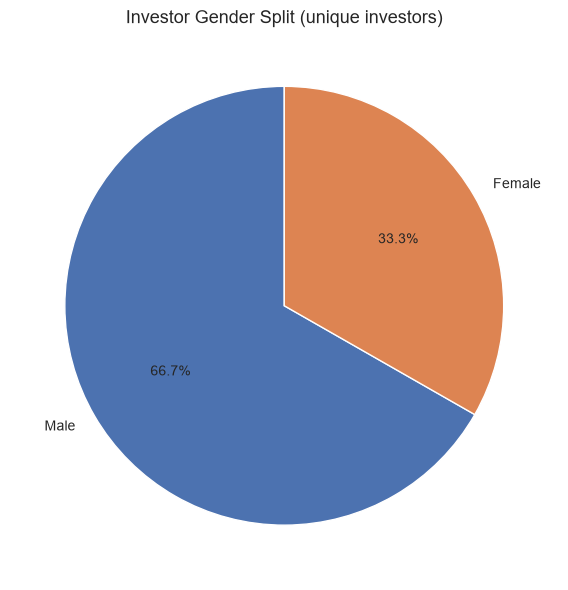

In [15]:
gender_counts = transactions.drop_duplicates(subset='investor_id')['gender'].value_counts()
print(gender_counts)
print((gender_counts / gender_counts.sum() * 100).round(1))

plt.figure(figsize=(6, 6))
plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4C72B0', '#DD8452']
)
plt.title("Investor Gender Split (unique investors)", fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "05d_gender_split_pie.png", dpi=150, bbox_inches='tight')
plt.show()

In [16]:
sip_only['sip_tier'] = sip_only['amount_inr'].apply(lambda x: 'High (≥40K)' if x >= 40000 else 'Low (<30K)')
print(sip_only.groupby('sip_tier')[['annual_income_lakh']].mean())
print(sip_only.groupby('sip_tier')['city_tier'].value_counts(normalize=True))

             annual_income_lakh
sip_tier                       
High (≥40K)           26.267746
Low (<30K)            26.388610
sip_tier     city_tier
High (≥40K)  T30          0.680295
             B30          0.319705
Low (<30K)   T30          0.664160
             B30          0.335840
Name: proportion, dtype: float64


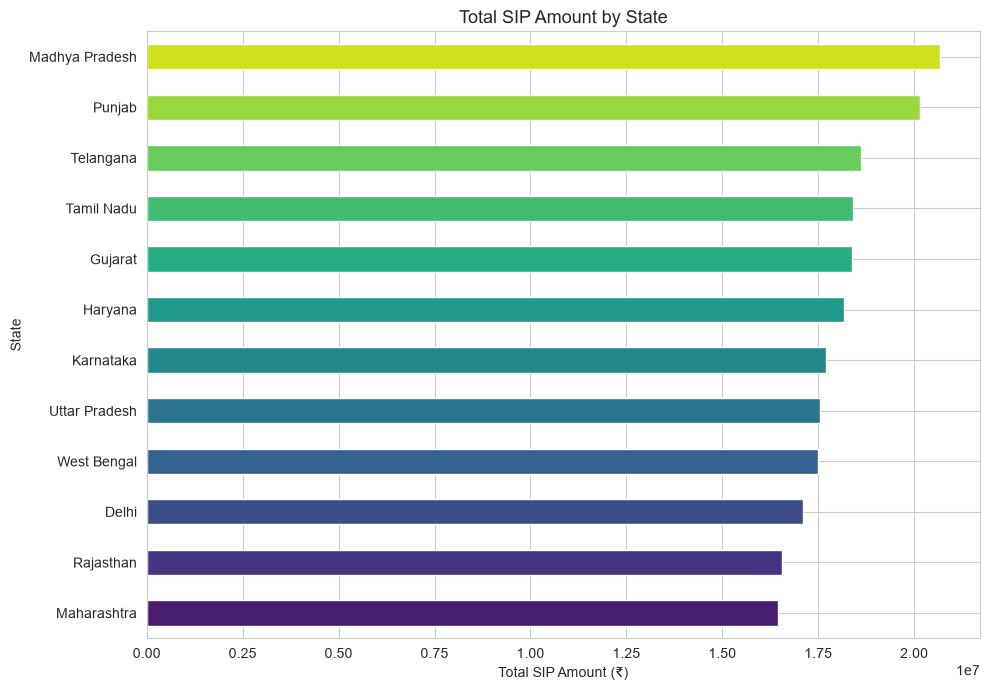

In [17]:
sip_by_state = sip_only.groupby('state')['amount_inr'].sum().sort_values(ascending=True)

plt.figure(figsize=(10, 7))
sip_by_state.plot(kind='barh', color=sns.color_palette('viridis', len(sip_by_state)))
plt.title("Total SIP Amount by State", fontsize=13)
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "06a_sip_by_state_barh.png", dpi=150, bbox_inches='tight')
plt.show()

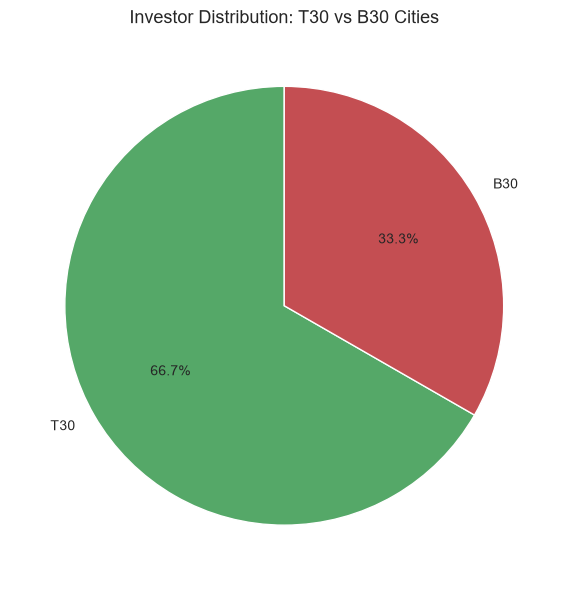

In [18]:
tier_counts = transactions.drop_duplicates(subset='investor_id')['city_tier'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    tier_counts.values,
    labels=tier_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#55A868', '#C44E52']
)
plt.title("Investor Distribution: T30 vs B30 Cities", fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "06b_t30_b30_pie.png", dpi=150, bbox_inches='tight')
plt.show()

In [19]:
print(folio_count.columns.tolist())
print(folio_count)

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
      month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0   2022-01               13.26                 9.28               1.86   
1   2022-04               13.91                 9.74               1.95   
2   2022-07               13.85                 9.69               1.94   
3   2022-10               14.12                 9.88               1.98   
4   2023-01               14.81                10.37               2.07   
5   2023-04               15.54                10.88               2.18   
6   2023-07               16.28                11.40               2.28   
7   2023-10               16.72                11.70               2.34   
8   2024-01               17.78                12.45               2.49   
9   2024-04               18.85                13.20               2.64   
10  2024-07               19.98                13.99 

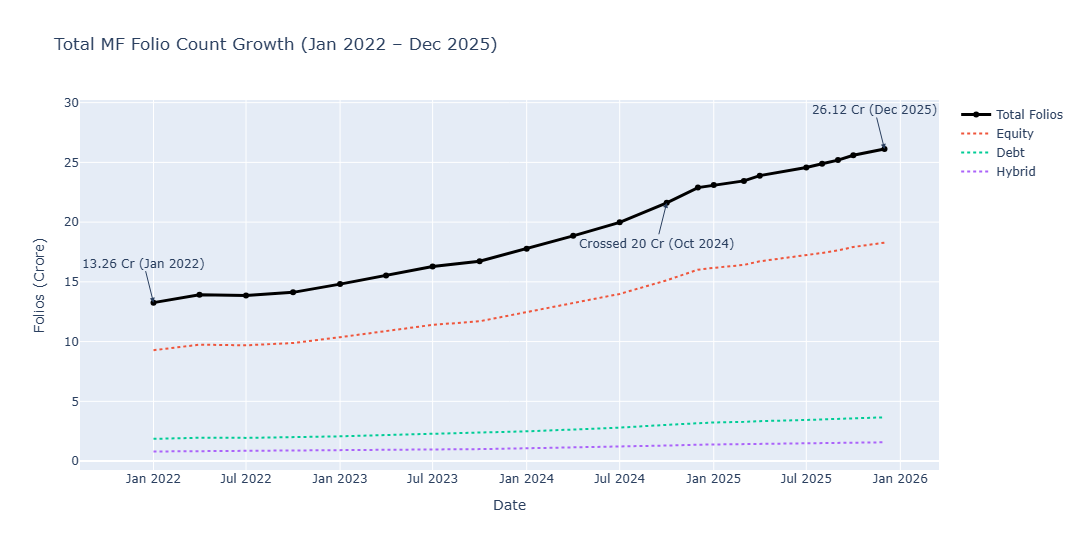

In [21]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=folio_count['month'], y=folio_count['total_folios_crore'],
    mode='lines+markers', name='Total Folios', line=dict(width=3, color='black')
))
fig.add_trace(go.Scatter(
    x=folio_count['month'], y=folio_count['equity_folios_crore'],
    mode='lines', name='Equity', line=dict(dash='dot')
))
fig.add_trace(go.Scatter(
    x=folio_count['month'], y=folio_count['debt_folios_crore'],
    mode='lines', name='Debt', line=dict(dash='dot')
))
fig.add_trace(go.Scatter(
    x=folio_count['month'], y=folio_count['hybrid_folios_crore'],
    mode='lines', name='Hybrid', line=dict(dash='dot')
))

# Mark the start and end milestones explicitly - convert Timestamp -> string for Plotly
start_date_str = folio_count['month'].iloc[0].strftime('%Y-%m-%d')
end_date_str = folio_count['month'].iloc[-1].strftime('%Y-%m-%d')

fig.add_annotation(x=start_date_str, y=folio_count['total_folios_crore'].iloc[0],
                    text="13.26 Cr (Jan 2022)", showarrow=True, arrowhead=2, ay=-40)
fig.add_annotation(x=end_date_str, y=folio_count['total_folios_crore'].iloc[-1],
                    text="26.12 Cr (Dec 2025)", showarrow=True, arrowhead=2, ay=-40)

# Mark crossing the 20 crore milestone
crossed_20 = folio_count[folio_count['total_folios_crore'] >= 20].iloc[0]
crossed_20_date_str = crossed_20['month'].strftime('%Y-%m-%d')

fig.add_annotation(x=crossed_20_date_str, y=crossed_20['total_folios_crore'],
                    text=f"Crossed 20 Cr ({crossed_20['month'].strftime('%b %Y')})",
                    showarrow=True, arrowhead=2, ay=40)

fig.update_layout(
    title="Total MF Folio Count Growth (Jan 2022 – Dec 2025)",
    xaxis_title="Date", yaxis_title="Folios (Crore)",
    height=550
)
fig.show()
fig.write_image(str(REPORTS_DIR / "07_folio_count_growth.png"), width=1300, height=650)

In [22]:
# Pick 10 funds - let's use the first 10 unique amfi_codes from fund_master for a representative spread
selected_codes = fund_master['amfi_code'].head(10).tolist()
print(selected_codes)

returns_subset = nav_with_names[nav_with_names['amfi_code'].isin(selected_codes)]

# Pivot to wide format: rows = date, columns = scheme_name, values = daily_return_pct
returns_wide = returns_subset.pivot(index='date', columns='scheme_name', values='daily_return_pct')

print(returns_wide.shape)
returns_wide.head()

[119551, 119552, 119598, 119599, 119120, 100016, 125497, 100033, 125498, 100025]
(1150, 10)


scheme_name,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,SBI Bluechip Fund - Direct Plan - Growth,SBI Bluechip Fund - Regular Plan - Growth,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Small Cap Fund - Direct Plan - Growth,SBI Small Cap Fund - Regular Plan - Growth
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.501034,-1.332796,-0.355285,0.100135,-1.030568,-1.830619,-0.070239,0.265074,-1.871621,-1.473511
2022-01-05,-0.518427,-0.438625,-0.004957,0.425036,1.286515,-0.510567,0.624685,0.441648,-0.113681,-0.516096
2022-01-06,-0.270616,-0.516686,-0.188009,-0.358896,-1.137747,-1.109101,1.404541,0.359824,-0.792439,0.482447
2022-01-07,-1.266043,-0.574832,0.203647,-0.271892,-0.120999,1.511102,-0.154720,-0.246536,-4.425211,3.282967


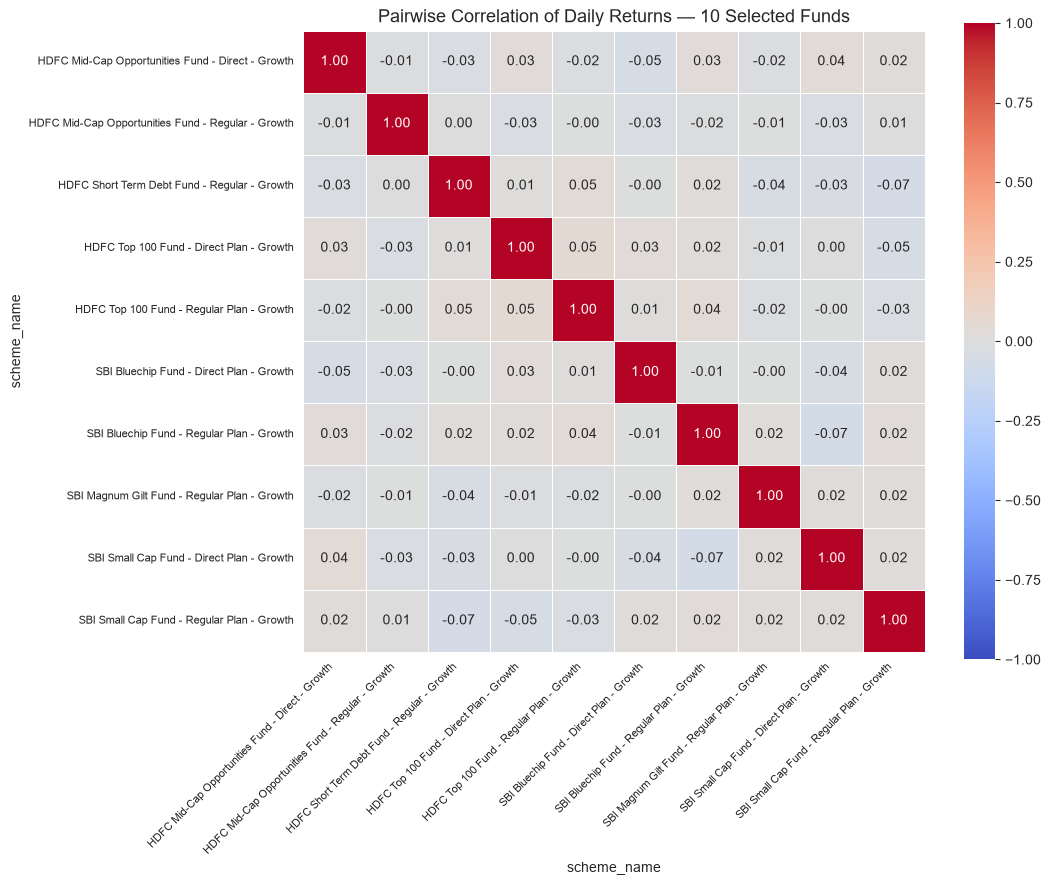

In [23]:
corr_matrix = returns_wide.corr()

plt.figure(figsize=(11, 9))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
plt.title("Pairwise Correlation of Daily Returns — 10 Selected Funds", fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "08_return_correlation_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# Find the pair with the lowest correlation
corr_unstacked = corr_matrix.where(~np.eye(len(corr_matrix), dtype=bool)).unstack().dropna()
lowest_pair = corr_unstacked.sort_values().head(2)  # head(2) because each pair appears twice (symmetric matrix)
print(lowest_pair)

scheme_name                                scheme_name                              
SBI Bluechip Fund - Regular Plan - Growth  SBI Small Cap Fund - Direct Plan - Growth   -0.072559
SBI Small Cap Fund - Direct Plan - Growth  SBI Bluechip Fund - Regular Plan - Growth   -0.072559
dtype: float64


In [25]:
print(fund_master[fund_master['amfi_code'].isin(selected_codes)][['scheme_name', 'category', 'sub_category']])

                                         scheme_name category    sub_category
0          SBI Bluechip Fund - Regular Plan - Growth   Equity       Large Cap
1           SBI Bluechip Fund - Direct Plan - Growth   Equity       Large Cap
2         SBI Small Cap Fund - Regular Plan - Growth   Equity       Small Cap
3          SBI Small Cap Fund - Direct Plan - Growth   Equity       Small Cap
4       SBI Magnum Gilt Fund - Regular Plan - Growth     Debt            Gilt
5          HDFC Top 100 Fund - Regular Plan - Growth   Equity       Large Cap
6           HDFC Top 100 Fund - Direct Plan - Growth   Equity       Large Cap
7  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   Equity         Mid Cap
8  HDFC Mid-Cap Opportunities Fund - Direct - Growth   Equity         Mid Cap
9       HDFC Short Term Debt Fund - Regular - Growth     Debt  Short Duration


In [26]:
debt_funds = ['SBI Magnum Gilt Fund - Regular Plan - Growth', 'HDFC Short Term Debt Fund - Regular - Growth']
print(corr_matrix[debt_funds])

scheme_name                                         SBI Magnum Gilt Fund - Regular Plan - Growth  \
scheme_name                                                                                        
HDFC Mid-Cap Opportunities Fund - Direct - Growth                                      -0.016315   
HDFC Mid-Cap Opportunities Fund - Regular - Growth                                     -0.007166   
HDFC Short Term Debt Fund - Regular - Growth                                           -0.040884   
HDFC Top 100 Fund - Direct Plan - Growth                                               -0.010542   
HDFC Top 100 Fund - Regular Plan - Growth                                              -0.022521   
SBI Bluechip Fund - Direct Plan - Growth                                               -0.004003   
SBI Bluechip Fund - Regular Plan - Growth                                               0.021601   
SBI Magnum Gilt Fund - Regular Plan - Growth                                            1.000000   


In [27]:
print(portfolio_holdings.columns.tolist())
print(portfolio_holdings.head())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']
   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  


In [28]:
sector_weights = portfolio_holdings.groupby('sector')['weight_pct'].sum().sort_values(ascending=False)

print(sector_weights)

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64


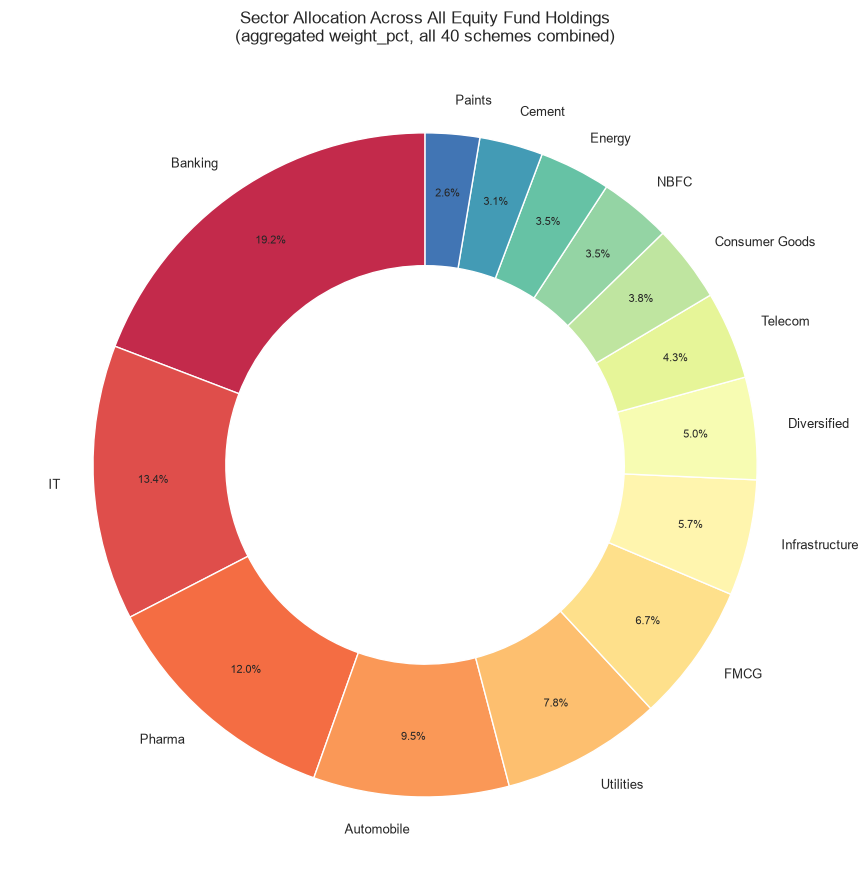

In [29]:
plt.figure(figsize=(9, 9))

colors = sns.color_palette('Spectral', len(sector_weights))

wedges, texts, autotexts = plt.pie(
    sector_weights.values,
    labels=sector_weights.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.82,
    wedgeprops=dict(width=0.4)  # this is what creates the "donut" hole
)

plt.setp(autotexts, size=8)
plt.setp(texts, size=9)

plt.title("Sector Allocation Across All Equity Fund Holdings\n(aggregated weight_pct, all 40 schemes combined)", fontsize=12)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "09_sector_allocation_donut.png", dpi=150, bbox_inches='tight')
plt.show()

## Key EDA Findings (Day 3)

1. **2023 was a clear bull run and 2024 showed a visible correction** across nearly all 40 schemes' NAV trends. (Chart 1: NAV Trend)

2. **SBI Mutual Fund is the dominant fund house by AUM**, reaching ₹12.50 lakh crore by the latest available period — consistent with the real-world AMFI figure cited for Dec 2025. (Chart 2: AUM by Fund House)

3. **Monthly SIP inflows hit an all-time high of ₹31,002 crore in Dec 2025**, the peak of a consistent upward trend since Jan 2022. (Chart 3: SIP Inflow Trend)

4. **Every fund category recorded positive net inflows every month in FY 2024-25** — no category saw net outflows, indicating broad-based investor confidence rather than rotation between categories. (Chart 4: Category Inflow Heatmap)

5. **Transaction frequency is broadly consistent across all age groups** — the distribution of transactions by age group nearly matches the distribution of unique investors by age group, meaning no age group transacts disproportionately more or less often. (Chart 5a/5b: Age Distribution)

6. **SIP amounts show a bimodal distribution with a near-total gap between ₹30,000–₹40,000**, but this is not explained by investor income or city tier (both segments average ~₹26.3L annual income and ~66-68% T30 representation) — likely a reflection of how the data was generated rather than a real behavioral pattern. (Chart 5c: SIP Amount by Age Boxplot)

7. **Madhya Pradesh leads in total SIP amount, while Punjab leads in transaction count** — meaning MP investors make fewer, larger-value transactions while Punjab investors transact more frequently at lower amounts. T30 cities account for ~67% of investors. (Chart 6a/6b: Geographic Distribution)

8. **Total MF folios grew from 13.26 crore (Jan 2022) to 26.12 crore (Dec 2025)**, crossing the 20 crore milestone in Oct 2024. Equity folios grew faster in absolute terms than Debt or Hybrid over the same period. (Chart 7: Folio Count Growth)

9. **Debt funds (Gilt, Short Duration) show near-zero correlation with all Equity funds** (range: -0.07 to +0.05 across all pairs tested), confirming genuine diversification value in mixing asset classes. Even within Equity, Large Cap vs Small Cap showed the lowest pairwise correlation (-0.07) in the sample, suggesting diversification benefits exist within equity allocation too. (Chart 8: Return Correlation Matrix)

10. **Banking (19.2%) and IT are the two largest sectors** across all equity fund holdings combined, consistent with real-world Indian equity mutual fund portfolio patterns. (Chart 9: Sector Allocation Donut)